# XC-ID Tutorial
**Date created:** 2025-10-23

**Author:** Jennifer Jiang

This is the Jupyter Notebook tutorial for running **XC-ID (X Chromosome inactivation - IDentifier)** [(Jiang and Gillis, 2025)]().

---
Running this notebook on a standard compute node or laptop should take less than a minute. All data used and generated in this tutorial can be found in `xc-id/data`, the **VCF** and **BAM** files are subsetted versions of the validation dataset used in the paper:

## Dependencies
XC-ID requires a working Python 3 environment. For installation, clone the [GitHub repository](https://github.com/jlhjiang/XC-ID.git) and install via `pip`:

```bash
git clone https://github.com/jlhjiang/XC-ID.git
cd XC-ID
pip install -e .
```

## Load libraries

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import xcid

In [2]:
# set working directory
base_dir = '../data'
os.chdir(base_dir)

## Provide input paths

Each individual sample should be processed separately. **XC-ID** requires the paths for: 
1. the **VCF** files provided to STAR+WASP, and
2. the resulting **WASP BAM** files. The index files (.bam.bai) should be located in the same directory.

These can be spread out across multiple files, they just need to be provided as a list.

In [3]:
bams = ['WASP_X.bam']
vcf_files = ['variants.vcf']

Users can optionally provide a line-delimited file of cell barcodes to consider, which can be the filtered STAR output.
This step is not necessary, but may help in denoising.

In [4]:
cells_file = 'barcodes.txt'

Additional parameters:

In [5]:
chromosome = 'X' # indicate right chromosome, this will vary across genome builds
rand_seed = 206 # for reproducibility

## Running XC-ID
We will provide the lists of paths to the XCID class.

In [6]:
xc = xcid.XCID(
    vcf_files=vcf_files,
    bam_files=bams,
    # everything below is optional
    cells_file='barcodes.txt',
    chromosome=chromosome,
    rand_seed=rand_seed,
)

Now we run the algorithm with the `.run_all()` function.

In [7]:
results = xc.run_all()

1. Loading data and constructing count matrices...
267 SNPs loaded from X
Number of filtered cells provided: 2000
Loaded 267 SNP positions with coverage.
Loaded 1968 cells with informative reads.
Filtered out 0 cells not in the filtered list.
Filtering SNPs based on minimum coverage=5, MAF=0.1
Final SNPs to phase: 265
Remaining informative cells: 1890 out of 1968.
2. Assigning haplotypes via simulated annealing...
Running simulated annealing with 1 initializations, 15000 max iterations.
Initial temperature: 265000, cooling rate: 0.995.
Iteration 0: cost=[-4400.]
Current temperature: 265000.0
Iteration 3750: cost=[-16142.]
Current temperature: 0.0
Iteration 7500: cost=[-16212.]
Current temperature: 0.0
Iteration 11250: cost=[-16212.]
Current temperature: 0.0
Best cost found after 14999 iterations: -16212.0. Initial cost: -4340.0.
3. Estimating confidence via bootstrapping...
Performing 100 bootstraps to determine cell confidence...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:    5.1s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.5s finished


4. Compiling results table...
Done!


The results table has the columns:
1. **cell_id:** these are the barcodes for the cells provided in the BAM file
2. **score:** this is a log ratio score for the count differences for either X alleles in a cell.
3. **p_value:** binomial p-values from bootstrapping.
4. **p_adj:** Benjamini-Hochberg corrected p-values.
5. **XCI_status:** the final calls for the active X allele within each cell. These are direction agnostic.

In [8]:
results.head(10)

,cell_id,score,p_value,p_adj,XCI_status
0,ATGTTTGAGGTTACGT,-4.087463,1.270427e-16,3.654652e-16,X1
1,AGGTTTGGTGGTGAGA,-0.584963,4.602054e-01,4.941978e-01,unknown
2,ACTCCTCAGACCATAC,-4.392317,1.531645e-17,5.132640e-17,X1
3,ACCCTGTTCTACCTGC,-2.807355,4.142226e-14,8.528112e-14,X1
4,ACAACAGAGGCTGTGC,3.169925,6.564908e-15,1.491307e-14,X0
5,CAACAGGCAGGATGGC,4.169925,3.224844e-24,1.218991e-22,X0
6,ATTGGTTCAGGCGATA,-3.700440,6.261623e-23,1.207599e-21,X1
7,AGGGCCTTCGGTAACT,-2.000000,2.412711e-13,4.550921e-13,X1
8,AGGCAATCACCGTTCC,3.321928,1.661024e-18,6.960834e-18,X0
9,AGGCAATCATGGAGGC,-4.392317,1.315433e-25,1.243085e-23,X1


Inspect the final assignment rates:

In [9]:
print(results['XCI_status'].value_counts())
conf = results.loc[results['XCI_status'] != 'unknown', :]
print(conf.shape[0], 'confident cells detected out of', results.shape[0], 'total cells.')

XCI_status
X1         1142
X0          537
unknown     211
Name: count, dtype: int64
1679 confident cells detected out of 1890 total cells.


## Visualization (optional)

Through this histogram, we see a clear bimodality in the haplotype ratio scores after bootstrapping filtration, indicating clear partitioning of X alleles.

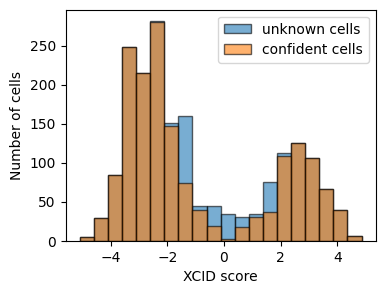

In [11]:
f = plt.figure(figsize=(4,3))
results['score'].hist(bins=20, label='unknown cells', 
                      alpha=0.6, edgecolor='black', linewidth=1)
conf['score'].hist(bins=20, label='confident cells', 
                   alpha=0.6, edgecolor='black', linewidth=1)
plt.xlabel('XCID score')
plt.ylabel('Number of cells')
plt.grid(None)
plt.legend()
plt.show()

## Saving results

Now we can save the results! 

This table can then be concatenated with the cell metadata in any downstream single-cell toolkits such Scanpy or seurat to perform X-lineage-stratified analyses.

In [12]:
os.makedirs('results', exist_ok=True)
results.to_csv('results/results.tsv', sep='\t', index=False)